In [25]:
#import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix,classification_report, roc_curve, roc_auc_score, precision_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/adult.csv')

print("Adult dataset loaded successfully.")

Adult dataset loaded successfully.


In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.shape

(32561, 15)

In [6]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 24


In [8]:
df.replace('?', np.nan, inplace=True)

In [9]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [10]:
categorical_cols = [
    'workclass',
    'occupation',
    'native.country'
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [12]:
df.drop(['fnlwgt'], axis=1, inplace=True)

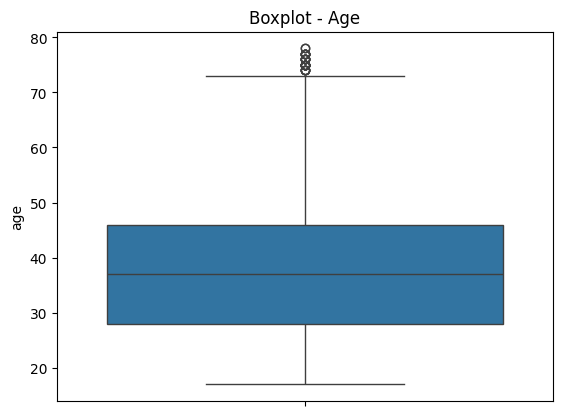

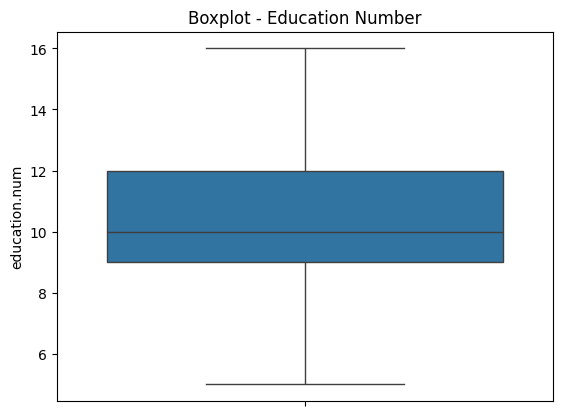

In [38]:
# Age
sns.boxplot(df['age'])
plt.title("Boxplot - Age")
plt.show()

# education.num
sns.boxplot(df['education.num'])
plt.title("Boxplot - Education Number")
plt.show()

In [41]:
# Remove outliers from age

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['age'] >= lower_limit) &
    (df['age'] <= upper_limit)
]

print("Shape after removing age outliers:", df.shape)

Shape after removing age outliers: (12407, 14)


In [42]:
# Remove outliers from education.num

Q1 = df['education.num'].quantile(0.25)
Q3 = df['education.num'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['education.num'] >= lower_limit) &
    (df['education.num'] <= upper_limit)
]

print("Shape after removing education.num outliers:", df.shape)

Shape after removing education.num outliers: (12407, 14)


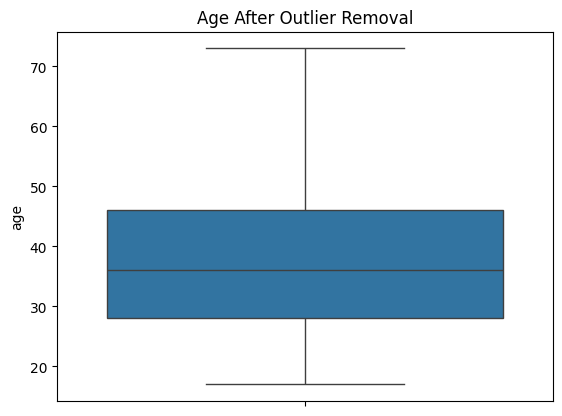

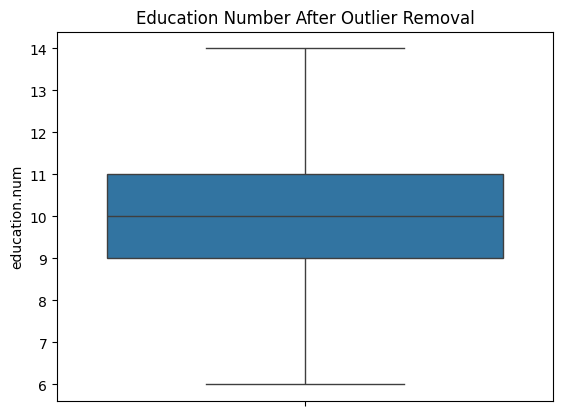

In [43]:
# Check age after removing outliers
sns.boxplot(df['age'])
plt.title("Age After Outlier Removal")
plt.show()

# Check education.num after removing outliers
sns.boxplot(df['education.num'])
plt.title("Education Number After Outlier Removal")
plt.show()

In [19]:
x = df.drop('income', axis=1)
y = df['income']

In [20]:
x = pd.get_dummies(x, drop_first=True)

In [21]:
le = LabelEncoder()
y = le.fit_transform(y)
print("Target classes:")
print(le.classes_)

Target classes:
['<=50K' '>50K']


In [23]:
# STANDARDIZATION
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [28]:
y_pred = knn.predict(x_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8290010193679919


In [30]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      3153
           1       0.57      0.52      0.55       771

    accuracy                           0.83      3924
   macro avg       0.73      0.71      0.72      3924
weighted avg       0.82      0.83      0.83      3924



Confusion Matrix:
[[2851  302]
 [ 369  402]]


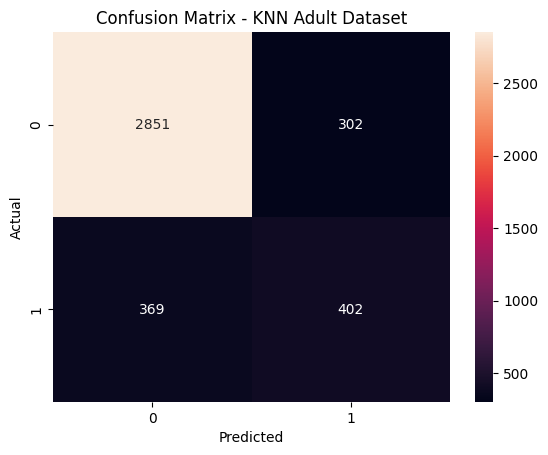

In [31]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Adult Dataset")
plt.show()

In [32]:
y_proba = knn.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.821230722145915


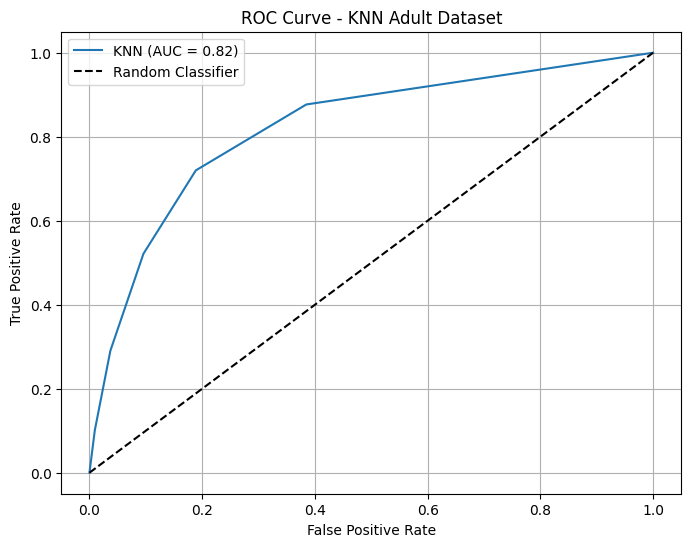

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'KNN (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN Adult Dataset")

plt.legend()
plt.grid()
plt.show()

In [36]:
overall_auc = roc_auc_score(y_test, y_proba)
print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 0.821230722145915
